# Classical MLP 1-layer Iris binary baseline

Classical baseline matched to the MZI/CNOT notebooks: same Iris split, scaling, optimizer, loss, timing, metrics, plots, and JSON export.


Iris Binary Classification | Classical MLP | 1 hidden layers
Input features: 4
Hidden layers: 1
Hidden width: 8
Trainable model parameters: 49
Architecture: IrisClassicalMLP(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)

[Local mode] Classical Adam training
Epoch 01/100 | train_loss=0.5157 | train_acc=1.000 | test_loss=0.3367 | test_acc=1.000 | time=0.023s
Epoch 02/100 | train_loss=0.2232 | train_acc=1.000 | test_loss=0.1101 | test_acc=1.000 | time=0.018s
Epoch 03/100 | train_loss=0.0671 | train_acc=1.000 | test_loss=0.0284 | test_acc=1.000 | time=0.014s
Epoch 04/100 | train_loss=0.0230 | train_acc=1.000 | test_loss=0.0110 | test_acc=1.000 | time=0.016s
Epoch 05/100 | train_loss=0.0117 | train_acc=1.000 | test_loss=0.0062 | test_acc=1.000 | time=0.015s
Epoch 06/100 | train_loss=0.0080 | train_acc=1.000 | test_loss=0.0041 | test_acc=1.000 | time=0.015s
Epoch 07/100 | tra

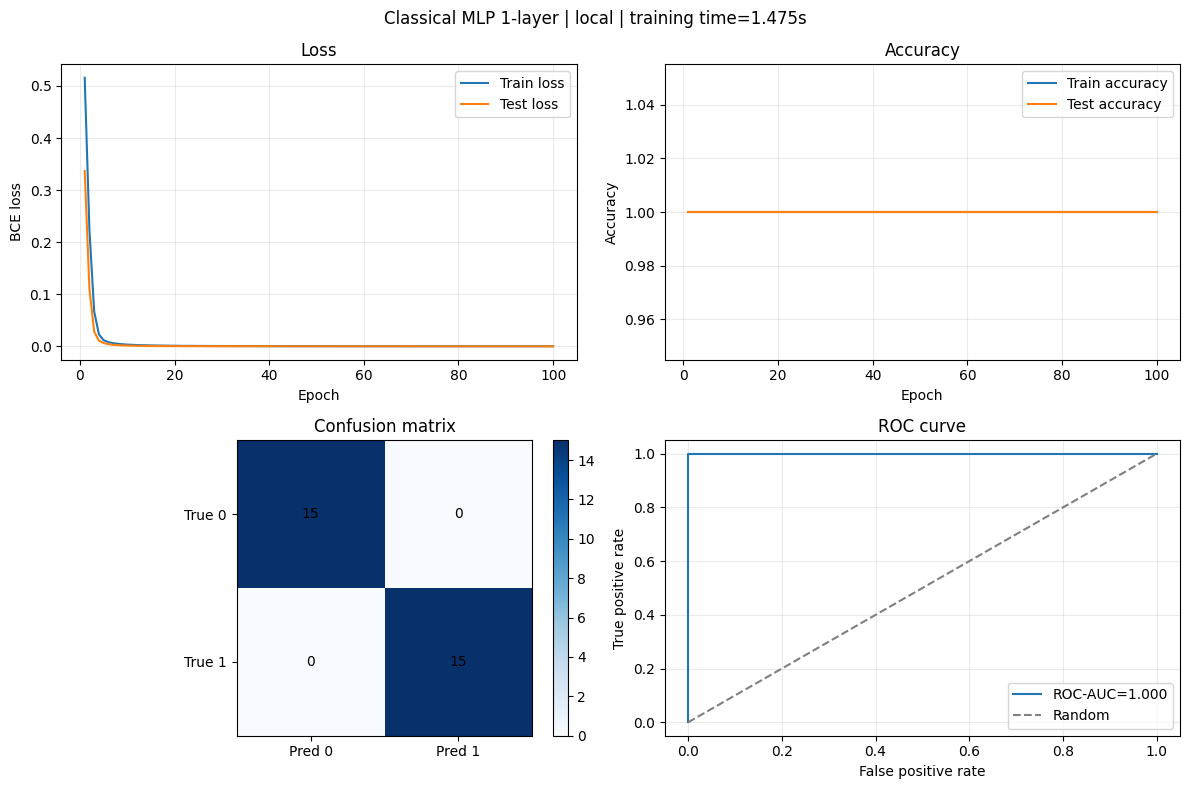

In [1]:
"""Iris binary classification with a classical multi-layer MLP baseline.

This notebook mirrors the MZI/CNOT training notebooks:
- Same Iris binary dataset: class 0 vs class 1.
- Same train/test split and feature scaling to [0, 2*pi].
- Same BCEWithLogitsLoss, Adam optimizer, epochs, batch size, metrics, timing, JSON export.
- N_LAYERS means the number of hidden Linear -> ReLU blocks.
"""

import json
import math
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris as sklearn_load_iris
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Configuration
# ============================================================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

N_FEATURES = 4
N_LAYERS = 1
HIDDEN_WIDTH = 8

IRIS_CLASS_0 = 0
IRIS_CLASS_1 = 1
TRAIN_SIZE = 70
TEST_SIZE = 30

LOCAL_EPOCHS = 100
LOCAL_BATCH_SIZE = 4
LOCAL_LR = 0.01

AUTO_PLOT = True
AUTO_SAVE_HISTORY = True
HISTORY_DIRECTORY = r"C:\Quantum"


# ============================================================
# Dataset: exactly the same split/scaling convention as MZI/CNOT
# ============================================================

def get_iris_binary_dataset():
    iris = sklearn_load_iris()
    x_all = iris.data.astype(np.float32)
    y_all = iris.target.astype(np.int64)

    mask = (y_all == IRIS_CLASS_0) | (y_all == IRIS_CLASS_1)
    x_all = x_all[mask]
    y_all = (y_all[mask] == IRIS_CLASS_1).astype(np.float32)

    x_train, x_test, y_train, y_test = train_test_split(
        x_all,
        y_all,
        train_size=TRAIN_SIZE,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y_all,
    )

    # Keep the same numerical input range used by the photonic angle encoding.
    scaler = MinMaxScaler(feature_range=(0.0, 2.0 * math.pi))
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    return (
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
    )


# ============================================================
# Classical multi-layer model
# ============================================================

class IrisClassicalMLP(nn.Module):
    def __init__(self, input_features=N_FEATURES, hidden_width=HIDDEN_WIDTH, n_layers=N_LAYERS):
        super().__init__()
        blocks = []
        in_features = input_features

        for layer_idx in range(1, n_layers + 1):
            blocks.append(nn.Linear(in_features, hidden_width))
            blocks.append(nn.ReLU())
            in_features = hidden_width

        blocks.append(nn.Linear(in_features, 1))
        self.network = nn.Sequential(*blocks)

    def forward(self, x):
        return self.network(x).view(-1)


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def model_architecture_summary(model):
    return {
        "family": "classical_mlp",
        "input_features": N_FEATURES,
        "hidden_layers": N_LAYERS,
        "hidden_width": HIDDEN_WIDTH,
        "activation": "ReLU",
        "output": "single_logit",
        "trainable_parameters": count_trainable_parameters(model),
    }


# ============================================================
# Metrics
# ============================================================

def metrics_from_logits(logits, targets, criterion):
    logits = logits.view(-1)
    targets = targets.view(-1)
    loss = criterion(logits, targets)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    accuracy = (predictions == targets).float().mean()
    return loss, accuracy, probabilities.detach().cpu(), predictions.detach().cpu()


def classification_metrics_from_probabilities(targets, probabilities):
    targets_np = targets.detach().cpu().numpy().astype(int).reshape(-1)
    probabilities_np = probabilities.detach().cpu().numpy().reshape(-1)
    predictions_np = (probabilities_np >= 0.5).astype(int)

    matrix = confusion_matrix(targets_np, predictions_np, labels=[0, 1])
    precision = precision_score(targets_np, predictions_np, zero_division=0)
    recall = recall_score(targets_np, predictions_np, zero_division=0)

    if len(np.unique(targets_np)) == 2:
        roc_auc = roc_auc_score(targets_np, probabilities_np)
        fpr, tpr, thresholds = roc_curve(targets_np, probabilities_np)
    else:
        roc_auc = float("nan")
        fpr, tpr, thresholds = np.array([]), np.array([]), np.array([])

    return {
        "confusion_matrix": matrix,
        "precision": float(precision),
        "recall": float(recall),
        "roc_auc": float(roc_auc),
        "roc_curve": {
            "fpr": fpr.tolist(),
            "tpr": tpr.tolist(),
            "thresholds": thresholds.tolist(),
        },
    }


def print_classification_metrics(label, targets, probabilities):
    metrics = classification_metrics_from_probabilities(targets, probabilities)
    matrix = metrics["confusion_matrix"]
    print(f"{label} confusion matrix [[TN, FP], [FN, TP]]: {matrix.tolist()}")
    print(f"{label} precision: {metrics['precision']:.4f}")
    print(f"{label} recall/sensitivity: {metrics['recall']:.4f}")
    print(f"{label} ROC-AUC: {metrics['roc_auc']:.4f}")
    return metrics


def evaluate_local(model, x, y, criterion):
    model.eval()
    with torch.no_grad():
        return metrics_from_logits(model(x), y, criterion)


# ============================================================
# Training
# ============================================================

def train_local(model, x_train, x_test, y_train, y_test):
    generator = torch.Generator().manual_seed(SEED)
    loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=LOCAL_BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )
    optimizer = optim.Adam(model.parameters(), lr=LOCAL_LR)
    criterion = nn.BCEWithLogitsLoss()
    total_start = time.time()

    history = {
        "mode": "local",
        "model_family": "CLASSICAL",
        "model_name": "classical_mlp",
        "layers": N_LAYERS,
        "architecture": model_architecture_summary(model),
        "dataset": {
            "name": "Iris",
            "classes": [IRIS_CLASS_0, IRIS_CLASS_1],
            "train_samples": int(len(x_train)),
            "test_samples": int(len(x_test)),
            "evaluated_test_samples": int(len(x_test)),
            "feature_scaling": "MinMaxScaler to [0, 2*pi]",
        },
        "training_config": {
            "optimizer": "Adam",
            "loss_function": "BCEWithLogitsLoss",
            "learning_rate": LOCAL_LR,
            "batch_size": LOCAL_BATCH_SIZE,
            "epochs": LOCAL_EPOCHS,
            "seed": SEED,
        },
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
        "epoch_time_s": [],
    }

    parameters_before = {
        name: parameter.detach().clone()
        for name, parameter in model.named_parameters()
        if parameter.requires_grad
    }

    training_start = time.time()
    for epoch in range(1, LOCAL_EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)

        train_loss = total_loss / len(x_train)
        _, train_acc, _, _ = evaluate_local(model, x_train, y_train, criterion)
        test_loss, test_acc, _, _ = evaluate_local(model, x_test, y_test, criterion)
        epoch_time = time.time() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(float(train_loss))
        history["train_accuracy"].append(float(train_acc.item()))
        history["test_loss"].append(float(test_loss.item()))
        history["test_accuracy"].append(float(test_acc.item()))
        history["epoch_time_s"].append(float(epoch_time))

        print(
            f"Epoch {epoch:02d}/{LOCAL_EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc.item():.3f} | "
            f"test_loss={test_loss.item():.4f} | test_acc={test_acc.item():.3f} | "
            f"time={epoch_time:.3f}s"
        )

    training_time = time.time() - training_start
    evaluation_start = time.time()
    test_loss, test_acc, probabilities, predictions = evaluate_local(
        model, x_test, y_test, criterion
    )
    evaluation_time = time.time() - evaluation_start
    total_wall_time = time.time() - total_start

    max_delta = max(
        (parameter.detach() - parameters_before[name]).abs().max().item()
        for name, parameter in model.named_parameters()
        if parameter.requires_grad
    )
    classification = print_classification_metrics("Local test", y_test, probabilities)

    history["timing"] = {
        "training_time_s": float(training_time),
        "evaluation_time_s": float(evaluation_time),
        "total_wall_time_s": float(total_wall_time),
    }
    history["final_test"] = {
        "loss": float(test_loss.item()),
        "accuracy": float(test_acc.item()),
        "precision": classification["precision"],
        "recall_sensitivity": classification["recall"],
        "roc_auc": classification["roc_auc"],
        "confusion_matrix": classification["confusion_matrix"].tolist(),
        "roc_curve": classification["roc_curve"],
        "probabilities": probabilities.tolist(),
        "predictions": predictions.tolist(),
        "labels": y_test.tolist(),
    }
    history["model_parameter_max_delta"] = float(max_delta)

    print(f"Local training time: {training_time:.3f}s")
    print(f"Local final evaluation time: {evaluation_time:.3f}s")
    print(f"Local total wall time: {total_wall_time:.3f}s")
    print("Model parameters updated:", max_delta > 0)
    print("Max |delta model parameters|:", max_delta)
    print(f"Final local loss={test_loss.item():.4f} | accuracy={test_acc.item():.3f}")
    print("Probabilities:", probabilities.tolist())
    print("Predictions  :", predictions.tolist())
    print("Labels       :", y_test.tolist())
    return history


# ============================================================
# History export and plots
# ============================================================

def save_history_json(history, path=None):
    if path is None:
        path = os.path.join(
            HISTORY_DIRECTORY,
            f"CLASSICAL-{N_LAYERS}layers-{history['mode']}-history.json",
        )
    with open(path, "w", encoding="utf-8") as file:
        json.dump(history, file, indent=2, ensure_ascii=False)
    print("History saved to:", path)
    return path


def plot_training_history(history):
    import matplotlib.pyplot as plt

    figure, axes = plt.subplots(2, 2, figsize=(12, 8))
    x_axis = history["epoch"]

    axes[0, 0].plot(x_axis, history["train_loss"], label="Train loss")
    axes[0, 0].plot(x_axis, history["test_loss"], label="Test loss")
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("BCE loss")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].plot(x_axis, history["train_accuracy"], label="Train accuracy")
    axes[0, 1].plot(x_axis, history["test_accuracy"], label="Test accuracy")
    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.25)

    matrix = np.array(history["final_test"]["confusion_matrix"])
    image = axes[1, 0].imshow(matrix, cmap="Blues")
    axes[1, 0].set_title("Confusion matrix")
    axes[1, 0].set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
    axes[1, 0].set_yticks([0, 1], labels=["True 0", "True 1"])
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            axes[1, 0].text(col, row, int(matrix[row, col]), ha="center", va="center")
    figure.colorbar(image, ax=axes[1, 0], fraction=0.046, pad=0.04)

    curve = history["final_test"].get("roc_curve", {})
    fpr = curve.get("fpr", [])
    tpr = curve.get("tpr", [])
    if fpr and tpr:
        axes[1, 1].plot(fpr, tpr, label=f"ROC-AUC={history['final_test']['roc_auc']:.3f}")
    axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    axes[1, 1].set_title("ROC curve")
    axes[1, 1].set_xlabel("False positive rate")
    axes[1, 1].set_ylabel("True positive rate")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.25)

    training_time = history["timing"]["training_time_s"]
    figure.suptitle(
        f"Classical MLP {N_LAYERS}-layer | local | training time={training_time:.3f}s"
    )
    figure.tight_layout()
    plt.show()
    return figure, axes


# ============================================================
# Main
# ============================================================

def main():
    print("=" * 68)
    print(f"Iris Binary Classification | Classical MLP | {N_LAYERS} hidden layers")
    print("=" * 68)

    x_train, x_test, y_train, y_test = get_iris_binary_dataset()
    model = IrisClassicalMLP()

    print("Input features:", N_FEATURES)
    print("Hidden layers:", N_LAYERS)
    print("Hidden width:", HIDDEN_WIDTH)
    print("Trainable model parameters:", count_trainable_parameters(model))
    print("Architecture:", model)

    print("\n[Local mode] Classical Adam training")
    history = train_local(model, x_train, x_test, y_train, y_test)
    return model, history


if __name__ == "__main__":
    MODEL, HISTORY = main()
    if AUTO_SAVE_HISTORY:
        HISTORY_PATH = save_history_json(HISTORY)
    if AUTO_PLOT:
        FIGURE, AXES = plot_training_history(HISTORY)
